In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\archit\Desktop\PROJECTS\customer churn project\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
print(df.isnull().values.any())


False


In [6]:
print(df['TotalCharges'].dtype)

object


In [7]:
print((df['TotalCharges'] == " ").sum())

11


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = 'coerce')

In [9]:
print((df['TotalCharges'] == " ").sum())

0


In [10]:
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

In [11]:
print(X)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

In [12]:
numerical_cols = X.select_dtypes(include =['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include = ['object']).columns

In [13]:
print(numerical_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [14]:
print(categorical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [16]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


In [17]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


In [18]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


In [19]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])


In [22]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)

Logistic Regression Accuracy: 0.8055358410220014


array([[926, 109],
       [165, 209]])

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [26]:
from sklearn.metrics import f1_score
print('Logistic Regression F1 Score:', f1_score(y_test, y_pred, pos_label='Yes'))

Logistic Regression F1 Score: 0.6040462427745664


In [27]:
from sklearn.metrics import make_scorer, f1_score, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

f1_scorer = make_scorer(f1_score, pos_label='Yes')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv_f1_scores = cross_val_score(model, X, y, cv=cv, scoring=f1_scorer)
log_cv_acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print('Cross-Validation F1 Scores:', log_cv_f1_scores)
print('Average CV F1 Score:', log_cv_f1_scores.mean())
print('Cross-Validation Accuracy Scores:', log_cv_acc_scores)
print('Average CV Accuracy Score:', log_cv_acc_scores.mean())

Cross-Validation F1 Scores: [0.61891117 0.61802575 0.63081395 0.55952381 0.57686676]
Average CV F1 Score: 0.6008282906290999
Cross-Validation Accuracy Scores: [0.81121363 0.8105039  0.81973031 0.78977273 0.79474432]
Average CV Accuracy Score: 0.8051929761597523


In [28]:
print('Logistic CV F1 mean:', log_cv_f1_scores.mean())
print('Logistic CV Accuracy mean:', log_cv_acc_scores.mean())

Logistic CV F1 mean: 0.6008282906290999
Logistic CV Accuracy mean: 0.8051929761597523


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score


In [30]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

In [31]:
rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [32]:
rf_pred = rf_model.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print('Random Forest Classification Report:')
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8041163946061036
Random Forest Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.91      0.87      1035
         Yes       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [33]:
rf_f1 = f1_score(y_test, rf_pred, pos_label='Yes')
print('Random Forest F1 Score:', rf_f1)

Random Forest F1 Score: 0.5868263473053892


In [34]:
f1_scorer = make_scorer(f1_score, pos_label='Yes')

rf_cv_f1_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=f1_scorer
)

rf_cv_acc_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print('Random Forest CV F1 Scores:', rf_cv_f1_scores)
print('Average RF CV F1 Score:', rf_cv_f1_scores.mean())
print('Random Forest CV Accuracy Scores:', rf_cv_acc_scores)
print('Average RF CV Accuracy Score:', rf_cv_acc_scores.mean())

Random Forest CV F1 Scores: [0.58910162 0.59530792 0.59732541 0.53495441 0.56842105]
Average RF CV F1 Score: 0.5770220812925115
Random Forest CV Accuracy Scores: [0.80198722 0.80411639 0.80766501 0.78267045 0.79616477]
Average RF CV Accuracy Score: 0.7985207715013873


SHAP values shape: (100, 45, 2)
X_test_sample shape: (100, 45)
Feature names count: 45


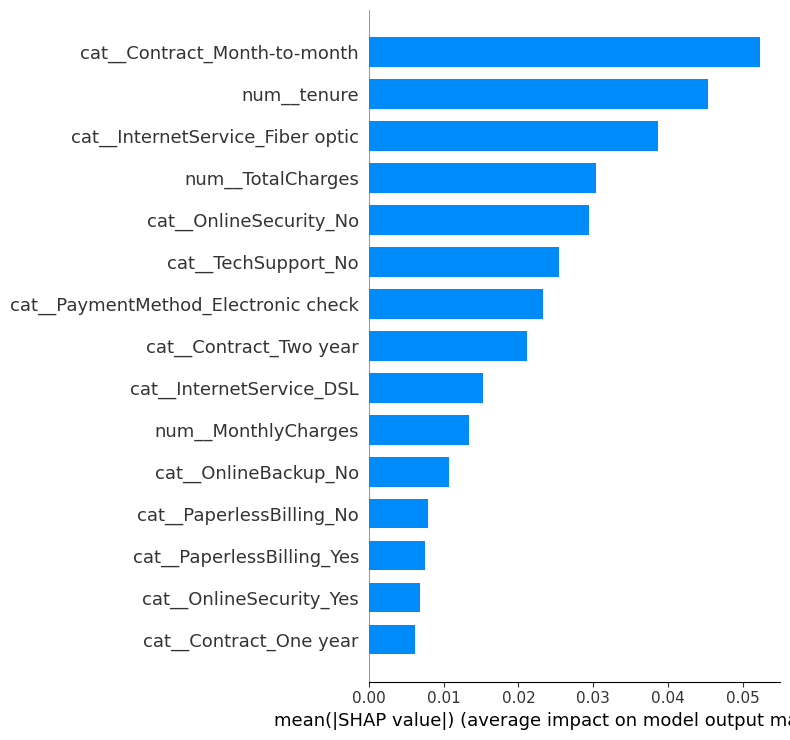

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np


rf_model_only = rf_model.named_steps['classifier']
X_test_transformed = rf_model.named_steps['preprocessor'].transform(X_test)

X_test_dense = X_test_transformed.astype(float)

# Use only 100 rows
X_test_sample = X_test_dense[:100]


feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()


explainer = shap.TreeExplainer(rf_model_only)
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)


print("SHAP values shape:", np.array(shap_values).shape)
print("X_test_sample shape:", X_test_sample.shape)
print("Feature names count:", len(feature_names))

# Plot
shap.summary_plot(shap_values[:, :, 1], X_test_sample,
                  feature_names=feature_names,
                  plot_type="bar",
                  max_display=15)
plt.tight_layout()
plt.savefig('shap_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
print('----- MODEL SUMMARY -----')
print('Logistic Regression -> Accuracy:', accuracy_score(y_test, y_pred), '| F1:', f1_score(y_test, y_pred, pos_label='Yes'))
print('Random Forest       -> Accuracy:', accuracy_score(y_test, rf_pred), '| F1:', f1_score(y_test, rf_pred, pos_label='Yes'))

----- MODEL SUMMARY -----
Logistic Regression -> Accuracy: 0.8055358410220014 | F1: 0.6040462427745664
Random Forest       -> Accuracy: 0.8041163946061036 | F1: 0.5868263473053892
